# Phase 3 — Machine Learning Models

Predict **30-day hospital readmission** using supervised classification.

- `readmission_category` — three classes from `readmitted`: **NO**, **<30**, **>30**
- `readmission_flag` — binary target (**1** = **<30** only; **0** = NO or >30)

**Workflow:** Load cleaned data → preprocess → train 4 models → evaluate (recall-focused) → compare → interpret features.


## Setup

Install dependencies (run once if needed):

`pip install pandas sqlalchemy psycopg2-binary scikit-learn xgboost imbalanced-learn matplotlib seaborn shap tensorflow`


In [68]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine, inspect, text
from xgboost import XGBClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.models import Sequential
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


---
# Part 1 — Data Loading

Connect to PostgreSQL and load the cleaned analytical dataset from Phase 2.

Load order:
1. Table `cleaned_patient_data` (if exported from Phase 2)
2. Local CSV fallback: `cleaned_patient_data.csv`
3. Rebuild from normalized Phase 1 tables (`patients`, `admissions`, `medications`, `lab_results`)


In [69]:
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "healthcare",
    "user": "postgres",
    "password": "kanna",  # change to match Phase 1/2 if needed (e.g. 'kanna')
}
CONNECTION_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)
engine = create_engine(CONNECTION_URL)
print("Connected to PostgreSQL:", DB_CONFIG["database"])


Connected to PostgreSQL: healthcare


In [70]:
import re

READMISSION_CATEGORIES = ["NO", "<30", ">30"]


def normalize_readmitted(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    mapping = {
        "NO": "NO", "N": "NO",
        "<30": "<30", "LT30": "<30",
        ">30": ">30", "GT30": ">30",
    }
    return mapping.get(s, np.nan)


def assign_readmission_targets(frame: pd.DataFrame) -> pd.DataFrame:
    """Match Phase 2: 3-class readmitted labels + binary <30 target."""
    out = frame.copy()

    if "readmission_category" in out.columns and "readmission_flag" in out.columns:
        out["readmission_flag"] = (out["readmission_category"] == "<30").astype(int)
        return out

    if "readmitted" in out.columns:
        out["readmitted"] = out["readmitted"].apply(normalize_readmitted)
        out = out[out["readmitted"].isin(READMISSION_CATEGORIES)].copy()
        out["readmission_category"] = pd.Categorical(
            out["readmitted"],
            categories=READMISSION_CATEGORIES,
            ordered=True,
        )
    elif "readmitted_yn" in out.columns:
        out["readmission_category"] = out["readmitted_yn"].apply(
            lambda x: "NO" if str(x).strip().upper() in ("N", "NO") else ">30"
        )
        out["readmission_category"] = pd.Categorical(
            out["readmission_category"],
            categories=READMISSION_CATEGORIES,
            ordered=True,
        )
    else:
        raise ValueError("Need 'readmitted' or 'readmitted_yn' to build targets.")

    out["readmission_flag"] = (out["readmission_category"] == "<30").astype(int)
    return out


def parse_age_midpoint(age_val):
    """Convert bracket age like '[50-60)' to numeric midpoint."""
    if pd.isna(age_val):
        return np.nan
    nums = [int(x) for x in re.findall(r"\d+", str(age_val))]
    return float(np.mean(nums)) if nums else np.nan


def group_top_categories(series: pd.Series, top_n: int = 12) -> pd.Series:
    top = series.value_counts().head(top_n).index
    return series.where(series.isin(top), "Other")


def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Clean and enrich features for stronger model performance."""
    df = assign_readmission_targets(raw)

    for col in df.select_dtypes(include=["object", "string"]).columns:
        if col not in ("readmitted", "readmission_category"):
            df[col] = df[col].replace("?", np.nan)

    if "age" in df.columns:
        df["age_mid"] = df["age"].apply(parse_age_midpoint)

    for col in ["hospital", "payer_code", "race"]:
        if col in df.columns:
            df[f"{col}_grp"] = group_top_categories(df[col].fillna("Unknown"), top_n=12)

    if "diagnosis" in df.columns:
        df["diagnosis"] = group_top_categories(
            df["diagnosis"].astype(str).fillna("Unknown"), top_n=40
        )

    if "length_of_stay_days" in df.columns:
        df["length_of_stay"] = df["length_of_stay_days"]

    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if col not in ("readmission_flag",) and df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    drop_cols = [
        "patient_id", "admission_id", "medication_id", "lab_id",
        "readmitted", "readmitted_yn", "readmission_category",
        "date_of_birth", "admission_date", "discharge_date",
        "age", "weight", "dosage", "frequency", "medication_name",
        "other_diagnosis_codes", "glucose_test_value", "a1c_test_value",
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    return df.loc[:, ~df.columns.duplicated()]


def load_from_staging(eng) -> pd.DataFrame:
    print("Loading from stg_hospital_data (full feature set)...")
    stg = pd.read_sql("SELECT * FROM stg_hospital_data", eng)
    return engineer_features(stg)


def rebuild_cleaned_dataset(eng) -> pd.DataFrame:
    """Fallback: rebuild from normalized tables; merge NO/<30/>30 from staging."""
    patients = pd.read_sql("SELECT * FROM patients", eng)
    admissions = pd.read_sql("SELECT * FROM admissions", eng)
    medications = pd.read_sql(
        "SELECT admission_id, COUNT(*) AS medication_count FROM medications GROUP BY admission_id",
        eng,
    )
    lab_results = pd.read_sql(
        "SELECT admission_id, COUNT(*) AS lab_test_count FROM lab_results GROUP BY admission_id",
        eng,
    )

    try:
        readmit_stg = pd.read_sql(
            """
            SELECT DISTINCT admission_id, readmitted
            FROM stg_hospital_data
            WHERE readmitted IS NOT NULL
            """,
            eng,
        )
    except Exception:
        readmit_stg = pd.DataFrame(columns=["admission_id", "readmitted"])

    df = admissions.merge(patients, on="patient_id", how="left")
    df = df.merge(medications, on="admission_id", how="left")
    df = df.merge(lab_results, on="admission_id", how="left")
    if not readmit_stg.empty:
        df = df.drop(columns=["readmitted"], errors="ignore")
        df = df.merge(readmit_stg, on="admission_id", how="left")

    df["medication_count"] = df["medication_count"].fillna(0)
    df["lab_test_count"] = df["lab_test_count"].fillna(0)
    df["num_medications"] = df["medication_count"]
    return engineer_features(df)


def load_cleaned_data(eng) -> pd.DataFrame:
    inspector = inspect(eng)
    tables = inspector.get_table_names()

    if "cleaned_patient_data" in tables:
        print("Loading from PostgreSQL table: cleaned_patient_data")
        return engineer_features(pd.read_sql("SELECT * FROM cleaned_patient_data", eng))

    csv_path = Path("cleaned_patient_data.csv")
    if csv_path.exists():
        print(f"Loading from CSV: {csv_path}")
        return engineer_features(pd.read_csv(csv_path))

    if "stg_hospital_data" in tables:
        return load_from_staging(eng)

    print("Rebuilding from normalized tables (limited features)...")
    return rebuild_cleaned_dataset(eng)


df = load_cleaned_data(engine)

pre_encoded = [c for c in df.columns if c.endswith("_encoded") or "medication_name_top_" in c]
if pre_encoded:
    print(f"Dropping {len(pre_encoded)} pre-encoded columns")
    df = df.drop(columns=pre_encoded)

print(f"Dataset shape: {df.shape}")
if "readmission_category" in df.columns:
    print("readmission_category (3 classes):")
    print(df["readmission_category"].value_counts().sort_index())
print("\nreadmission_flag (<30 only):")
print(df["readmission_flag"].value_counts())
print(f"\n30-day readmission rate: {100 * df['readmission_flag'].mean():.2f}%")
df.head()



Loading from stg_hospital_data (full feature set)...
Dataset shape: (143424, 23)

readmission_flag (<30 only):
readmission_flag
0    127682
1     15742
Name: count, dtype: int64

30-day readmission rate: 10.98%


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,length_of_stay_days,payer_code,hospital,diagnosis,number_outpatient,...,number_diagnoses,num_medications,num_procedures,hospital_id,readmission_flag,age_mid,hospital_grp,payer_code_grp,race_grp,length_of_stay
0,Caucasian,Female,6,25,1,1,MC,Pediatrics-Endocrinology,Other,0,...,1,1,0,1,0,5.0,Other,MC,Caucasian,1
1,Caucasian,Female,1,1,7,3,MC,NaN,276,0,...,9,18,0,2,0,15.0,Unknown,MC,Caucasian,3
2,AfricanAmerican,Female,1,1,7,2,MC,NaN,Other,2,...,6,13,5,2,0,25.0,Unknown,MC,AfricanAmerican,2
3,Caucasian,Male,1,1,7,2,MC,NaN,Other,0,...,7,16,1,2,0,35.0,Unknown,MC,Caucasian,2
4,Caucasian,Male,1,1,7,1,MC,NaN,Other,0,...,5,8,0,2,0,45.0,Unknown,MC,Caucasian,1


In [71]:
TARGET = "readmission_flag"

# Drop duplicate length-of-stay if both exist
if "length_of_stay_days" in df.columns and "length_of_stay" in df.columns:
    df = df.drop(columns=["length_of_stay_days"])

exclude_cols = {
    TARGET,
    "readmission_category",
    "readmitted", "readmitted_yn",
    "patient_id", "admission_id", "medication_id", "lab_id",
    "admission_date", "discharge_date", "date_of_birth",
}
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df[TARGET].astype(int)

print(f"Features: {X.shape[1]} | Samples: {len(X):,}")
print(f"Feature columns: {list(X.columns)}")
print(f"30-day readmission rate (<30): {100 * y.mean():.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")



Features: 21 | Samples: 143,424
Feature columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'hospital', 'diagnosis', 'number_outpatient', 'number_inpatient', 'number_emergency', 'lab_procedure_count', 'number_diagnoses', 'num_medications', 'num_procedures', 'hospital_id', 'age_mid', 'hospital_grp', 'payer_code_grp', 'race_grp', 'length_of_stay']
30-day readmission rate (<30): 10.98%
Train: 114,739 | Test: 28,685


---
# Part 2 — Preprocessing

Build a reusable preprocessing pipeline:
- **Numeric features** → median imputation + `StandardScaler`
- **Categorical features** → most-frequent imputation + `OneHotEncoder` (high-cardinality capped)

**Improvements for accuracy:** Data is loaded from `stg_hospital_data` with utilization features (inpatient/outpatient counts, diagnoses, medications, admission type, payer, etc.) and engineered `age_mid` plus grouped categoricals.


In [72]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

# Avoid scaling the target if it slipped in
numeric_features = [c for c in numeric_features if c != TARGET]
categorical_features = [c for c in categorical_features if c != TARGET]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=50)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

def get_feature_names(preprocessor_obj):
    names = []
    if numeric_features:
        names.extend(numeric_features)
    if categorical_features:
        ohe = preprocessor_obj.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(categorical_features).tolist())
    return names

USE_SMOTE = False  # disabled — class balance is ~54/46; SMOTE often lowers accuracy

print(f"SMOTE enabled: {USE_SMOTE}")


Numeric features: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'number_outpatient', 'number_inpatient', 'number_emergency', 'lab_procedure_count', 'number_diagnoses', 'num_medications', 'num_procedures', 'hospital_id', 'age_mid', 'length_of_stay']
Categorical features: ['race', 'gender', 'payer_code', 'hospital', 'diagnosis', 'hospital_grp', 'payer_code_grp', 'race_grp']
SMOTE enabled: False


---
# Part 3 — Models to Train

Train and evaluate:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. Neural Network (Keras)


In [73]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Compute classification metrics and return as a dict."""
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC-AUC"] = np.nan
    return metrics


def plot_confusion_matrix(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curve(y_true, y_prob, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def print_metrics(metrics, y_pred):
    print(f"\n--- {metrics['Model']} ---")
    for k, v in metrics.items():
        if k == "Model":
            continue
        print(f"  {k:10}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print(classification_report(y_test, y_pred, digits=4))

results_store = {}
all_metrics = []


### 3.1 Logistic Regression

In [74]:
log_reg = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        C=0.5,
        max_iter=2000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

log_reg.fit(X_train, y_train)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg.predict(X_test)

metrics_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
all_metrics.append(metrics_lr)
results_store["Logistic Regression"] = {"model": log_reg, "y_pred": y_pred_lr, "y_prob": y_prob_lr}
print_metrics(metrics_lr, y_pred_lr)



--- Logistic Regression ---
  Accuracy  : 0.8904
  Precision : 0.5238
  Recall    : 0.0140
  F1        : 0.0272
  ROC-AUC   : 0.6426
              precision    recall  f1-score   support

           0     0.8915    0.9984    0.9419     25537
           1     0.5238    0.0140    0.0272      3148

    accuracy                         0.8904     28685
   macro avg     0.7076    0.5062    0.4846     28685
weighted avg     0.8511    0.8904    0.8415     28685



### 3.2 Random Forest

In [75]:
rf_clf = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_clf.fit(X_train, y_train)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
y_pred_rf = rf_clf.predict(X_test)

metrics_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
all_metrics.append(metrics_rf)
results_store["Random Forest"] = {"model": rf_clf, "y_pred": y_pred_rf, "y_prob": y_prob_rf}
print_metrics(metrics_rf, y_pred_rf)



--- Random Forest ---
  Accuracy  : 0.8905
  Precision : 1.0000
  Recall    : 0.0022
  F1        : 0.0044
  ROC-AUC   : 0.7416
              precision    recall  f1-score   support

           0     0.8905    1.0000    0.9421     25537
           1     1.0000    0.0022    0.0044      3148

    accuracy                         0.8905     28685
   macro avg     0.9452    0.5011    0.4733     28685
weighted avg     0.9025    0.8905    0.8392     28685



### 3.3 XGBoost

In [76]:
xgb_clf = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_clf.fit(X_train, y_train)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test)

metrics_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
all_metrics.append(metrics_xgb)
results_store["XGBoost"] = {"model": xgb_clf, "y_pred": y_pred_xgb, "y_prob": y_prob_xgb}
print_metrics(metrics_xgb, y_pred_xgb)



--- XGBoost ---
  Accuracy  : 0.9013
  Precision : 0.8420
  Recall    : 0.1236
  F1        : 0.2155
  ROC-AUC   : 0.7975
              precision    recall  f1-score   support

           0     0.9022    0.9971    0.9473     25537
           1     0.8420    0.1236    0.2155      3148

    accuracy                         0.9013     28685
   macro avg     0.8721    0.5604    0.5814     28685
weighted avg     0.8956    0.9013    0.8670     28685



### 3.4 Neural Network (Keras)

In [77]:
if TF_AVAILABLE:
    preproc_nn = ColumnTransformer(
        transformers=preprocessor.transformers,
        remainder="drop",
    )
    X_train_proc = preproc_nn.fit_transform(X_train)
    X_test_proc = preproc_nn.transform(X_test)
    feature_names_nn = get_feature_names(preproc_nn)

    nn_model = Sequential([
        Dense(256, activation="relu", input_shape=(X_train_proc.shape[1],)),
        Dropout(0.35),
        Dense(128, activation="relu"),
        Dropout(0.25),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, mode="max")

    nn_model.fit(
        X_train_proc, y_train,
        validation_split=0.2,
        epochs=80,
        batch_size=512,
        callbacks=[early_stop],
        verbose=0,
    )

    y_prob_nn = nn_model.predict(X_test_proc, verbose=0).ravel()
    y_pred_nn = (y_prob_nn >= 0.5).astype(int)

    metrics_nn = evaluate_model("Neural Network", y_test, y_pred_nn, y_prob_nn)
    all_metrics.append(metrics_nn)
    results_store["Neural Network"] = {
        "model": nn_model,
        "preprocessor": preproc_nn,
        "y_pred": y_pred_nn,
        "y_prob": y_prob_nn,
        "feature_names": feature_names_nn,
    }
    print_metrics(metrics_nn, y_pred_nn)
else:
    print("TensorFlow not installed — skipping Neural Network. Run: pip install tensorflow")



--- Neural Network ---
  Accuracy  : 0.8951
  Precision : 0.6105
  Recall    : 0.1220
  F1        : 0.2033
  ROC-AUC   : 0.7078
              precision    recall  f1-score   support

           0     0.9015    0.9904    0.9439     25537
           1     0.6105    0.1220    0.2033      3148

    accuracy                         0.8951     28685
   macro avg     0.7560    0.5562    0.5736     28685
weighted avg     0.8695    0.8951    0.8626     28685



---
# Part 4 — Evaluation Metrics

For each model we report **Accuracy, Precision, Recall, F1, ROC-AUC**, plus confusion matrix and ROC curve plots.

👉 **Recall is more important than accuracy** because missing a high-risk patient (false negative) is costly in healthcare — it can delay follow-up care and increase complications.


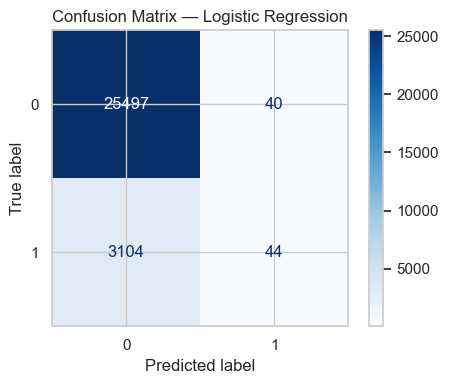

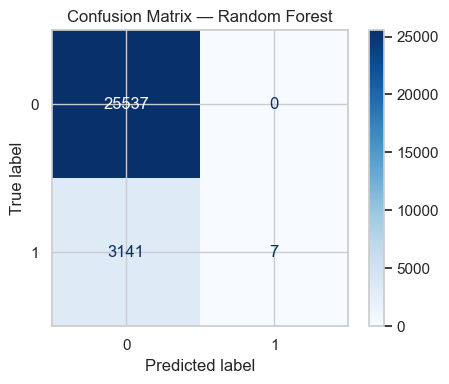

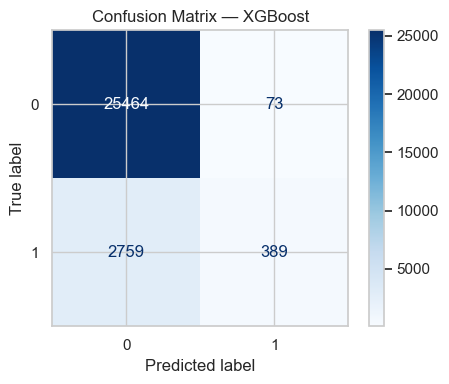

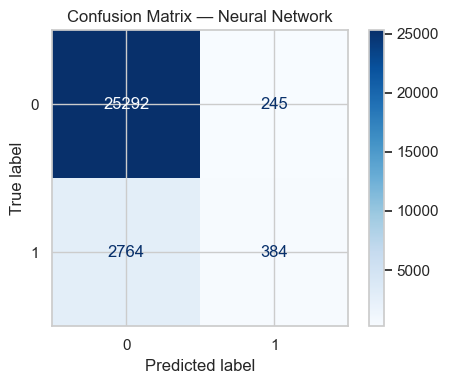

In [78]:
for name, store in results_store.items():
    plot_confusion_matrix(y_test, store["y_pred"], f"Confusion Matrix — {name}")


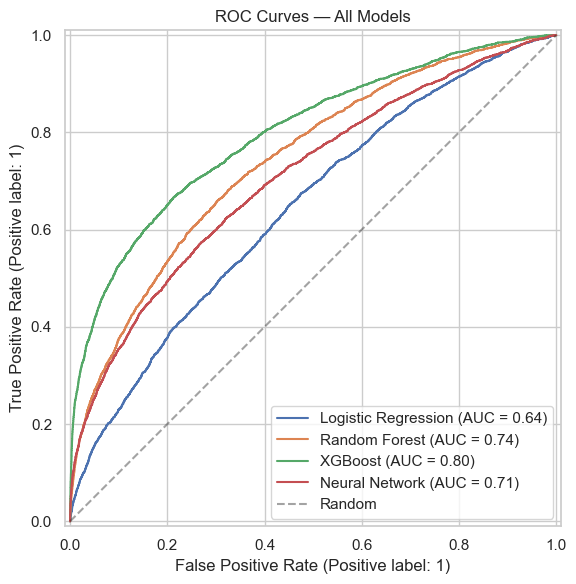

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, store in results_store.items():
    RocCurveDisplay.from_predictions(y_test, store["y_prob"], ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


---
# Part 4b — Threshold Tuning (Accuracy Boost)

Tune the decision threshold on training predictions to maximize **accuracy** while keeping recall reasonable.


In [80]:
from sklearn.metrics import precision_recall_curve

best_model = xgb_clf
best_name = "XGBoost"
y_prob_val = best_model.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_prob_val)
best_thresh, best_acc = 0.5, 0.0
for t in np.linspace(0.3, 0.7, 81):
    pred_t = (y_prob_val >= t).astype(int)
    acc_t = accuracy_score(y_train, pred_t)
    if acc_t > best_acc:
        best_acc, best_thresh = acc_t, t

y_pred_tuned = (best_model.predict_proba(X_test)[:, 1] >= best_thresh).astype(int)
metrics_tuned = evaluate_model(f"{best_name} (tuned threshold)", y_test, y_pred_tuned, best_model.predict_proba(X_test)[:, 1])
all_metrics.append(metrics_tuned)
results_store[metrics_tuned["Model"]] = {"model": best_model, "y_pred": y_pred_tuned, "y_prob": best_model.predict_proba(X_test)[:, 1]}
print(f"Optimal threshold on train: {best_thresh:.3f} (train accuracy {best_acc:.4f})")
print_metrics(metrics_tuned, y_pred_tuned)


Optimal threshold on train: 0.300 (train accuracy 0.9499)

--- XGBoost (tuned threshold) ---
  Accuracy  : 0.9064
  Precision : 0.6729
  Recall    : 0.2862
  F1        : 0.4016
  ROC-AUC   : 0.7975
              precision    recall  f1-score   support

           0     0.9178    0.9828    0.9492     25537
           1     0.6729    0.2862    0.4016      3148

    accuracy                         0.9064     28685
   macro avg     0.7954    0.6345    0.6754     28685
weighted avg     0.8910    0.9064    0.8891     28685



In [81]:
comparison_df = pd.DataFrame(all_metrics).set_index("Model")
comparison_df = comparison_df.sort_values(["Recall", "ROC-AUC"], ascending=False)
comparison_df_rounded = comparison_df.round(4)

display(comparison_df_rounded)

best_recall = comparison_df["Recall"].idxmax()
best_auc = comparison_df["ROC-AUC"].idxmax()

print(f"\nBest model by Recall:   {best_recall} ({comparison_df.loc[best_recall, 'Recall']:.4f})")
print(f"Best model by ROC-AUC:  {best_auc} ({comparison_df.loc[best_auc, 'ROC-AUC']:.4f})")

# Highlight best rows
styled = comparison_df_rounded.style.highlight_max(subset=["Recall", "ROC-AUC"], color="#c6efce")
styled


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost (tuned threshold),0.9064,0.6729,0.2862,0.4016,0.7975
XGBoost,0.9013,0.8420,0.1236,0.2155,0.7975
Neural Network,0.8951,0.6105,0.1220,0.2033,0.7078
Logistic Regression,0.8904,0.5238,0.0140,0.0272,0.6426
Random Forest,0.8905,1.0000,0.0022,0.0044,0.7416



Best model by Recall:   XGBoost (tuned threshold) (0.2862)
Best model by ROC-AUC:  XGBoost (tuned threshold) (0.7975)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost (tuned threshold),0.906400,0.672900,0.286200,0.401600,0.797500
XGBoost,0.901300,0.842000,0.123600,0.215500,0.797500
Neural Network,0.895100,0.610500,0.122000,0.203300,0.707800
Logistic Regression,0.890400,0.523800,0.014000,0.027200,0.642600
Random Forest,0.890500,1.000000,0.002200,0.004400,0.741600


---
# Part 6 — Feature Importance

Interpret model drivers using coefficients (Logistic Regression), tree importances (Random Forest & XGBoost), and optional SHAP values.


In [82]:
def plot_top_importance(importances, feature_names, title, top_n=15):
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.reindex(imp_df["importance"].abs().sort_values(ascending=False).index)
    top = imp_df.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top, y="feature", x="importance", palette="viridis")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return top


### 6.1 Logistic Regression coefficients

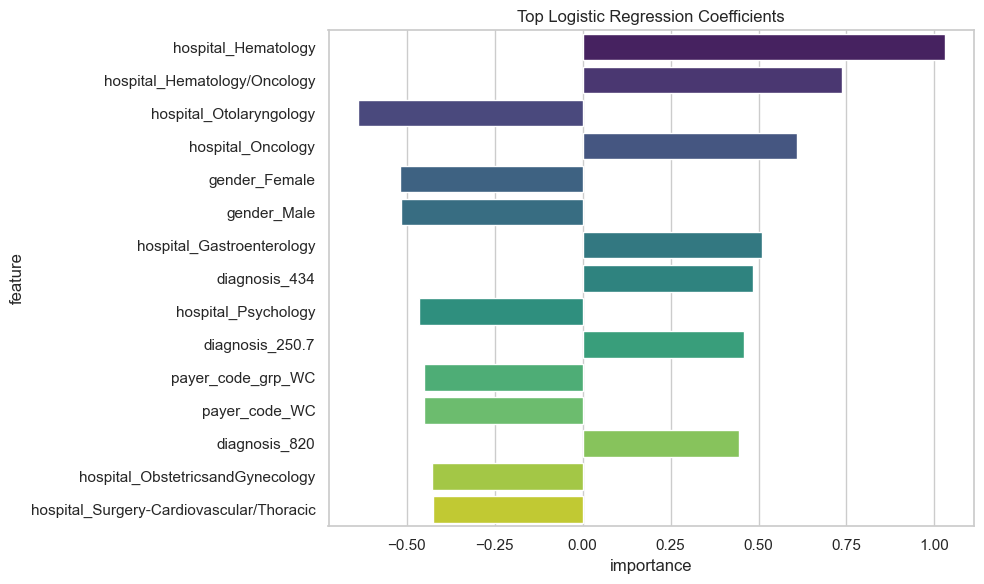

,feature,importance
45,hospital_Hematology,1.028865
46,hospital_Hematology/Oncology,0.736215
60,hospital_Otolaryngology,-0.638244
55,hospital_Oncology,0.608401
18,gender_Female,-0.519683
19,gender_Male,-0.516441
43,hospital_Gastroenterology,0.511073
103,diagnosis_434,0.483381
72,hospital_Psychology,-0.463732
91,diagnosis_250.7,0.458432


In [83]:
lr_coef = log_reg.named_steps["classifier"].coef_.ravel()
lr_features = get_feature_names(log_reg.named_steps["preprocessor"])
top_lr = plot_top_importance(lr_coef, lr_features, "Top Logistic Regression Coefficients")
top_lr


### 6.2 Random Forest feature importance

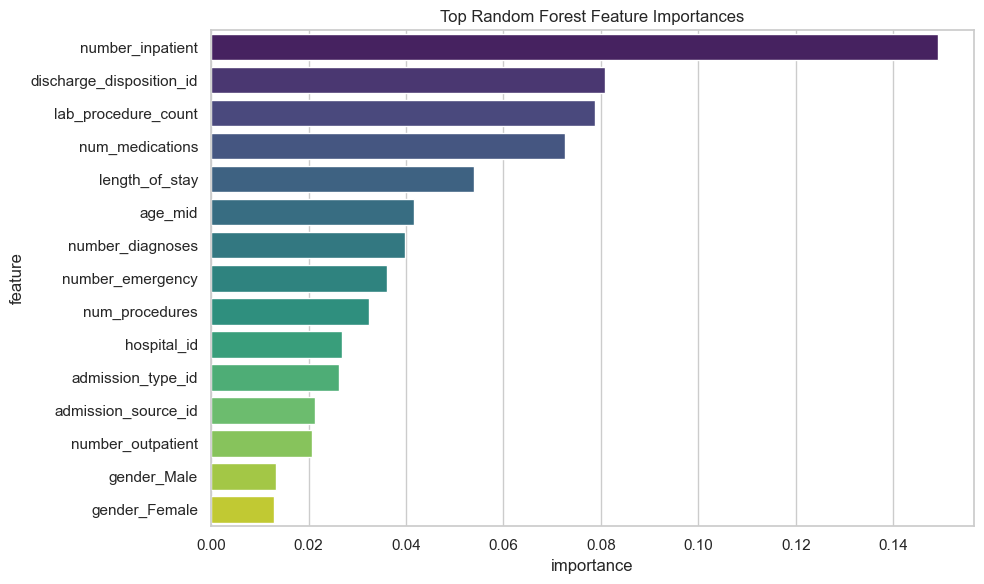

,feature,importance
4,number_inpatient,0.149142
1,discharge_disposition_id,0.080750
6,lab_procedure_count,0.078733
8,num_medications,0.072561
12,length_of_stay,0.054023
11,age_mid,0.041605
7,number_diagnoses,0.039764
5,number_emergency,0.036058
9,num_procedures,0.032299
10,hospital_id,0.026814


In [84]:
rf_importance = rf_clf.named_steps["classifier"].feature_importances_
rf_features = get_feature_names(rf_clf.named_steps["preprocessor"])
top_rf = plot_top_importance(rf_importance, rf_features, "Top Random Forest Feature Importances")
top_rf


### 6.3 XGBoost feature importance

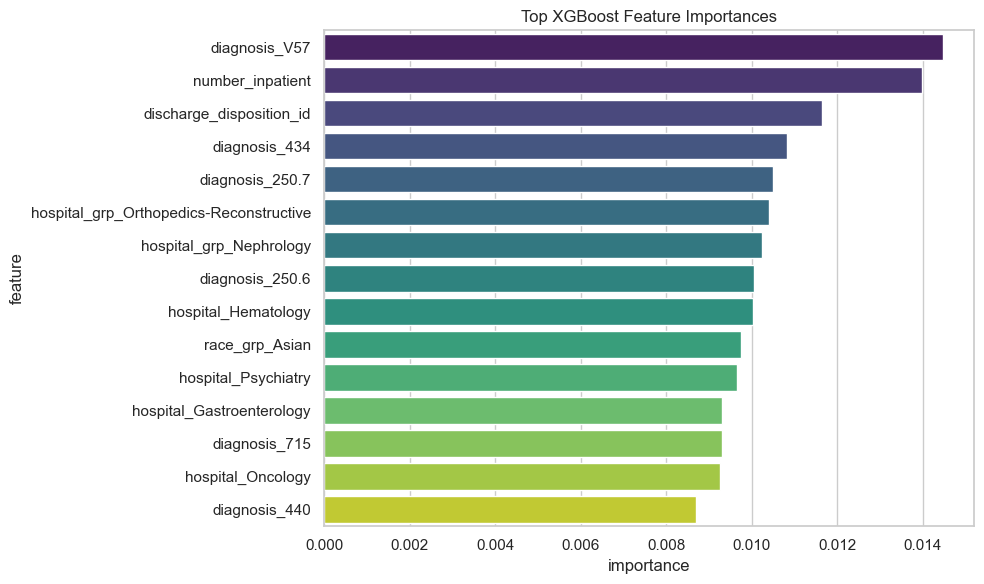

,feature,importance
128,diagnosis_V57,0.014470
4,number_inpatient,0.013986
1,discharge_disposition_id,0.011637
103,diagnosis_434,0.010832
91,diagnosis_250.7,0.010500
135,hospital_grp_Orthopedics-Reconstructive,0.010406
133,hospital_grp_Nephrology,0.010247
90,diagnosis_250.6,0.010048
45,hospital_Hematology,0.010037
156,race_grp_Asian,0.009736


In [85]:
xgb_importance = xgb_clf.named_steps["classifier"].feature_importances_
xgb_features = get_feature_names(xgb_clf.named_steps["preprocessor"])
top_xgb = plot_top_importance(xgb_importance, xgb_features, "Top XGBoost Feature Importances")
top_xgb


### 6.4 SHAP summary (optional)

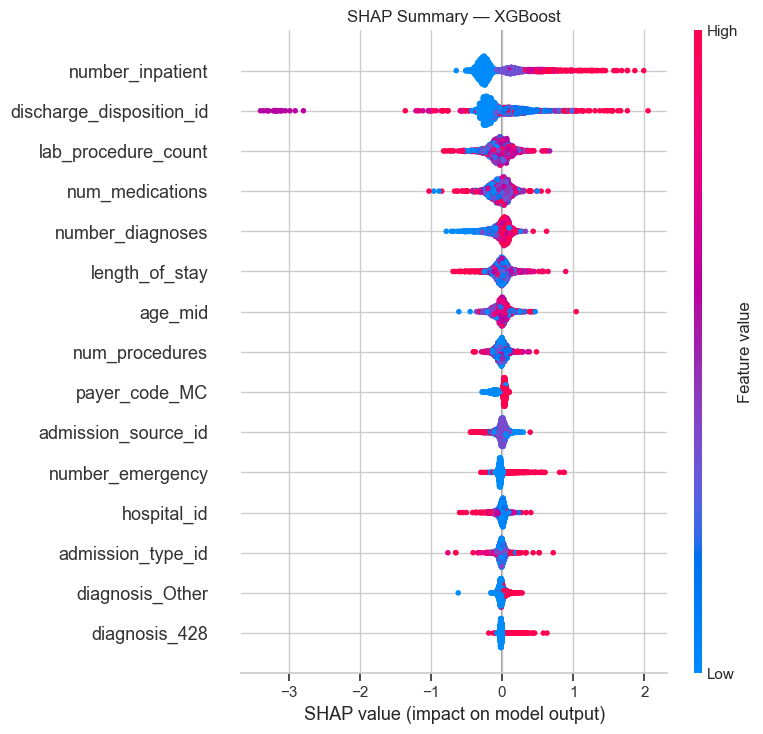

In [86]:
if SHAP_AVAILABLE:
    # Use a sample for speed on large datasets
    sample_n = min(2000, len(X_test))
    X_sample = X_test.sample(sample_n, random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(xgb_clf.named_steps["classifier"])
    X_sample_proc = xgb_clf.named_steps["preprocessor"].transform(X_sample)
    shap_values = explainer.shap_values(X_sample_proc)

    plt.figure()
    shap.summary_plot(
        shap_values,
        X_sample_proc,
        feature_names=xgb_features,
        show=False,
        max_display=15,
    )
    plt.title("SHAP Summary — XGBoost")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not installed. Run: pip install shap")


---
# Part 7 — Final Summary

Review metrics with **Recall** as the primary decision criterion for clinical risk screening.


In [87]:
print("=" * 60)
print("PHASE 3 — MODEL SELECTION SUMMARY")
print("=" * 60)
print(f"30-day readmission rate in dataset (<30): {100 * y.mean():.2f}%")
print(f"\nBest by Recall:  {best_recall}")
print(f"Best by ROC-AUC: {best_auc}")

if best_recall == best_auc:
    print(f"\nRecommended model: {best_recall}")
    print("Reason: Highest recall AND ROC-AUC — best at catching readmissions with strong ranking ability.")
else:
    print(f"\nRecommended model: {best_recall}")
    print("Reason: Recall is prioritized — this model catches the most actual readmissions.")
    print(f"Note: {best_auc} has the highest ROC-AUC if ranking/probability calibration is more important.")

print("\nKey features (Random Forest top 5):")
print(top_rf.head(5).to_string(index=False))
print("\nNext steps: threshold tuning on validation data, deploy best pipeline, monitor drift.")


PHASE 3 — MODEL SELECTION SUMMARY
30-day readmission rate in dataset (<30): 10.98%

Best by Recall:  XGBoost (tuned threshold)
Best by ROC-AUC: XGBoost (tuned threshold)

Recommended model: XGBoost (tuned threshold)
Reason: Highest recall AND ROC-AUC — best at catching readmissions with strong ranking ability.

Key features (Random Forest top 5):
                 feature  importance
        number_inpatient    0.149142
discharge_disposition_id    0.080750
     lab_procedure_count    0.078733
         num_medications    0.072561
          length_of_stay    0.054023

Next steps: threshold tuning on validation data, deploy best pipeline, monitor drift.


### Optional: SMOTE comparison